In [131]:
import os
from tqdm import tqdm
import json

os.environ["HF_HUB_CACHE"] = "/mnt/md0/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/mnt/md0/hf_cache/"
os.environ["HF_TOKEN"] = "$HF_TOKEN"

from transformers import AutoTokenizer
from datasets import load_dataset

In [132]:
tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-120b")

## nvidia/Nemotron-SFT-SWE-v2

In [ ]:
# hf download nvidia/Nemotron-SFT-SWE-v2 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-SFT-SWE-v2/snapshots/bd151f3f2d89c4804dda0083d912bd9f6a0a9fb7/data/"

agentless_samples = []
with open(os.path.join(data_path, "agentless.jsonl"), "r") as f:
    for line in tqdm(f):
        agentless_samples.append(json.loads(line.strip()))

swe_samples = []
with open(os.path.join(data_path, "swe.jsonl"), "r") as f:
    for line in tqdm(f):
        swe_samples.append(json.loads(line.strip()))

In [57]:
# Using only agentless for pretraining, since SWE doesn't have the reasoning content and we aren't doing SDG

In [201]:
def clean_messages(messages, strip_null_tools: bool = False):
    for message in messages:
        if "reasoning_content" in message:
            message["thinking"] = message.pop("reasoning_content")
        if message.get("content") is None:
            message["content"] = ""
        if message.get("thinking") is None:
            message["thinking"] = ""
        if strip_null_tools and len(message.get("tool_calls", [])) == 0:
            message.pop("tool_calls", None)
    # Remove any turns marked "assistant" that have no content, thinking, or tool calls, since these are likely artifacts of the data collection process and don't provide useful signal for pretraining.
    # Mutate the messages object in place to ensure changes propagate to the sample dict that contains it.
    messages[:] = [m for m in messages if not (m["role"] == "assistant" and m["content"] == "" and m["thinking"] == "" and len(m.get("tool_calls", [])) == 0)]
    return messages

def clean_tools(tools):
    """Recursively remove None values from tool schemas (e.g. default: null)."""
    if isinstance(tools, dict):
        return {k: clean_tools(v) for k, v in tools.items() if v is not None}
    if isinstance(tools, list):
        return [clean_tools(t) for t in tools]
    return tools


In [ ]:
swe_agentless_all = open("sft-swe-v2-agentless.jsonl", "w")
swe_agentless_4k = open("sft-swe-v2-agentless-4k.jsonl", "w")
swe_agentless_8k = open("sft-swe-v2-agentless-8k.jsonl", "w")

# Preprocessing pass: efficient
chat_templated_samples = []
for sample in tqdm(agentless_samples):
    messages = clean_messages(sample["messages"])

    # Count number of tokens in sample
    templated = tokenizer.apply_chat_template(messages, tokenize=False)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(agentless_samples, num_tokens_per_sample), total=len(agentless_samples)):
    dump_sample = json.dumps(sample)
    swe_agentless_all.write(dump_sample + "\n")
    if num_tokens < 4096:
        swe_agentless_4k.write(dump_sample + "\n")
    if num_tokens < 8192:
        swe_agentless_8k.write(dump_sample + "\n")

swe_agentless_all.close()
swe_agentless_4k.close()
swe_agentless_8k.close()

## nvidia/Nemotron-SFT-Agentic-v2

In [133]:
# hf download nvidia/Nemotron-SFT-Agentic-v2 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-SFT-Agentic-v2/snapshots/49e79a3be5ab8cf7511a12958b95cfd6408cd8db/data/"

interactive_agent_samples = []
with open(os.path.join(data_path, "interactive_agent.jsonl"), "r") as f:
    for line in tqdm(f):
        try:
            interactive_agent_samples.append(json.loads(line.strip()))
        except:
            continue

search_samples = []
with open(os.path.join(data_path, "search.jsonl"), "r") as f:
    for line in tqdm(f):
        try:
            search_samples.append(json.loads(line.strip()))
        except:
            continue

tool_calling_samples = []
with open(os.path.join(data_path, "tool_calling.jsonl"), "r") as f:
    for line in tqdm(f):
        try:
            tool_calling_samples.append(json.loads(line.strip()))
        except:
            continue

278880it [01:40, 2765.53it/s] 
5968it [00:01, 3699.30it/s]
8444it [00:00, 8678.71it/s] 


In [ ]:
len(interactive_agent_samples), len(search_samples), len(tool_calling_samples)

(278880, 5968, 8443)

In [ ]:
# Both Interactive Agent and Search samples are fairly short seqlen and have reasoning content
# Search samples are super long and probably better suited for RL phase

In [160]:
interactive_all = open("sft-agentic-v2-interactive.jsonl", "w")
interactive_4k = open("sft-agentic-v2-interactive-4k.jsonl", "w")

# Preprocessing pass: efficient
chat_templated_samples = []
for sample in tqdm(interactive_agent_samples):
    messages = clean_messages(sample["messages"])
    tools = clean_tools(sample.get("tools", []))

    templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(interactive_agent_samples, num_tokens_per_sample), total=len(interactive_agent_samples)):
    if sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    interactive_all.write(dump_sample + "\n")
    if num_tokens < 4096:
        interactive_4k.write(dump_sample + "\n")

interactive_all.close()
interactive_4k.close()

100%|██████████| 278878/278878 [00:24<00:00, 11241.71it/s]


In [165]:
tool_calling_all = open("sft-agentic-v2-tool-calling.jsonl", "w")
tool_calling_4k = open("sft-agentic-v2-tool-calling-4k.jsonl", "w")

# Preprocessing pass: efficient
chat_templated_samples = []
for sample in tqdm(tool_calling_samples):
    messages = clean_messages(sample["messages"])
    tools = clean_tools(sample.get("tools", []))

    templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(tool_calling_samples, num_tokens_per_sample), total=len(tool_calling_samples)):
    if sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    tool_calling_all.write(dump_sample + "\n")
    if num_tokens < 4096:
        tool_calling_4k.write(dump_sample + "\n")

tool_calling_all.close()
tool_calling_4k.close()

100%|██████████| 8443/8443 [00:00<00:00, 11234.69it/s]


## nvidia/Nemotron-Math-v2

In [166]:
# GPT-OSS-120B traces for low, medium, and high reasoning effort.
# Some problems have multiple entries in each split, so we use a set to remove the duplicates at each reasoning level.
# Duplicates across levels are okay for now, and may be filtered out in later stages.

# hf download nvidia/Nemotron-Math-v2 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-Math-v2/snapshots/8e793210e175b6406c752a870f585f62de98c0d3/data"

high_problem_ids = set()
high_samples = []
for fname in ("high.part_00.jsonl", "high.part_01.jsonl", "high.part_02.jsonl"):
    with open(os.path.join(data_path, fname), "r") as f:
        for line in tqdm(f):
            try:
                sample = json.loads(line.strip())
                if sample["problem"] not in high_problem_ids:
                    high_samples.append(sample)
                    high_problem_ids.add(sample["problem"])
            except:
                continue

medium_problem_ids = set()
medium_samples = []
with open(os.path.join(data_path, "medium.jsonl"), "r") as f:
    for line in tqdm(f):
        try:
            sample = json.loads(line.strip())
            if sample["problem"] not in medium_problem_ids:
                medium_samples.append(sample)
                medium_problem_ids.add(sample["problem"])
        except:
            continue

low_problem_ids = set()
low_samples = []
with open(os.path.join(data_path, "low.jsonl"), "r") as f:
    for line in tqdm(f):
        try:
            sample = json.loads(line.strip())
            if sample["problem"] not in low_problem_ids:
                low_samples.append(sample)
                low_problem_ids.add(sample["problem"])
        except:
            continue

695908it [01:38, 7033.65it/s] 
1071924it [01:21, 13208.24it/s]
1097543it [01:19, 13775.62it/s]
2502305it [01:27, 28630.73it/s]
1718159it [01:08, 25100.24it/s]


In [175]:
# An acceptable number of samples for each reasoning level, after deduplication.
len(high_samples), len(medium_samples), len(low_samples)

(313851, 292482, 267772)

In [215]:
reasoning_medium_all = open("math-v2-medium.jsonl", "w")
reasoning_medium_4k = open("math-v2-medium-4k.jsonl", "w")

# Preprocessing pass: efficient
chat_templated_samples = []
for sample in tqdm(medium_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True, reasoning_effort="medium")
    except Exception:
        # Some very rare cases of broken tool calls in this dataset (1 in a million), so we skip those.
        chat_templated_samples.append(None)
        continue
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    batch_to_tokenize = [b for b in batch if b is not None]
    tokenized = tokenizer(batch_to_tokenize, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        if batch[i] is None:
            num_tokens_per_sample.append(0)
            num_skipped += 1
        else:
            num_tokens = len(tokenized["input_ids"][i - num_skipped])
            num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(medium_samples, num_tokens_per_sample), total=len(medium_samples)):
    if num_tokens == 0:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    sample["reasoning_effort"] = "medium"
    dump_sample = json.dumps(sample)
    reasoning_medium_all.write(dump_sample + "\n")
    if num_tokens < 4096:
        reasoning_medium_4k.write(dump_sample + "\n")

reasoning_medium_all.close()
reasoning_medium_4k.close()

100%|██████████| 292482/292482 [00:12<00:00, 22892.12it/s]


In [216]:
reasoning_low_all = open("math-v2-low.jsonl", "w")
reasoning_low_4k = open("math-v2-low-4k.jsonl", "w")

# Preprocessing pass: efficient
chat_templated_samples = []
for sample in tqdm(low_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True, reasoning_effort="low")
    except Exception:
        # Some very rare cases of broken tool calls in this dataset (1 in a million), so we skip those.
        chat_templated_samples.append(None)
        continue
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    batch_to_tokenize = [b for b in batch if b is not None]
    tokenized = tokenizer(batch_to_tokenize, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        if batch[i] is None:
            num_tokens_per_sample.append(0)
            num_skipped += 1
        else:
            num_tokens = len(tokenized["input_ids"][i - num_skipped])
            num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(low_samples, num_tokens_per_sample), total=len(low_samples)):
    if num_tokens == 0:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    sample["reasoning_effort"] = "low"
    dump_sample = json.dumps(sample)
    reasoning_low_all.write(dump_sample + "\n")
    if num_tokens < 4096:
        reasoning_low_4k.write(dump_sample + "\n")

reasoning_low_all.close()
reasoning_low_4k.close()

100%|██████████| 267772/267772 [00:07<00:00, 35868.01it/s]


## nvidia/Nemotron-Competitive-Programming-v1

In [224]:
# Has three splits: competitive coding CPP, competitive coding Python, and Infinibyte.
# All of them may end up exceeding context for pretrain run, so we'll load only the first 1000 samples from each to check.

# hf download nvidia/Nemotron-Competitive-Programming-v1 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-Competitive-Programming-v1/snapshots/d6e7c6b404ed5db6e1104b41d0f80a0c7dad7bf8/data/"

cpp_samples = []
for fname in ("competitive_coding_cpp.part_00.jsonl", "competitive_coding_cpp.part_01.jsonl"):
    with open(os.path.join(data_path, fname), "r") as f:
        for line in tqdm(f):
            try:
                sample = json.loads(line.strip())
                cpp_samples.append(sample)
                # if len(cpp_samples) >= 1000:
                #     break
            except:
                continue

python_samples = []
for fname in ("competitive_coding_python.part_00.jsonl", "competitive_coding_python.part_01.jsonl"):
    with open(os.path.join(data_path, fname), "r") as f:
        for line in tqdm(f):
            try:
                sample = json.loads(line.strip())
                python_samples.append(sample)
                # if len(python_samples) >= 1000:
                #     break
            except:
                continue

infinibyte_samples = []
for fname in ("infinibyte.part_00.jsonl", "infinibyte.part_01.jsonl"):
    with open(os.path.join(data_path, fname), "r") as f:
        for line in tqdm(f):
            try:
                sample = json.loads(line.strip())
                infinibyte_samples.append(sample)
                # if len(infinibyte_samples) >= 1000:
                #     break
            except:
                continue

466006it [00:36, 12672.06it/s]
466006it [00:39, 11938.61it/s]
910639it [01:07, 13471.60it/s]
910639it [01:40, 9026.44it/s] 
587347it [00:49, 11835.84it/s]
587347it [00:49, 11793.00it/s]


In [225]:
cpp_4k = open("competitive-coding-v1-cpp-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(cpp_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    if len(templated) > 20000:
        # Heuristic: we are only keeping samples with < 4k context length.
        # Most samples are super long, so we use a simple heuristic based on the length of the templated string
        # before we run the expensive tokenization step
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    cpp_4k.write(dump_sample + "\n")

cpp_4k.close()

100%|██████████| 175090/175090 [00:02<00:00, 62864.63it/s]


In [226]:
python_4k = open("competitive-coding-v1-python-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(python_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    if len(templated) > 30000:
        # Heuristic: we are only keeping samples with < 4k context length.
        # Most samples are super long, so we use a simple heuristic based on the length of the templated string
        # before we run the expensive tokenization step
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    python_4k.write(dump_sample + "\n")

python_4k.close()

100%|██████████| 663676/663676 [00:07<00:00, 92825.89it/s]


In [227]:
infinibyte_4k = open("competitive-coding-v1-infinibyte-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(infinibyte_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    if len(templated) > 30000:
        # Heuristic: we are only keeping samples with < 4k context length.
        # Most samples are super long, so we use a simple heuristic based on the length of the templated string
        # before we run the expensive tokenization step
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    infinibyte_4k.write(dump_sample + "\n")

infinibyte_4k.close()

100%|██████████| 435804/435804 [00:03<00:00, 128474.58it/s]


## nvidia/Nemotron-SFT-Instruction-Following-Chat-v2

In [228]:
# Use the reasoning-on subset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-SFT-Instruction-Following-Chat-v2/snapshots/1a9454ed054b8544503ab8d8c0a519d141a44c5b/data/"

chat_samples = []
with open(os.path.join(data_path, "reasoning_on.jsonl"), "r") as f:
    for line in tqdm(f):
        chat_samples.append(json.loads(line.strip()))

929237it [00:27, 34303.16it/s]


In [237]:
chat_4k = open("sft-if-chat-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(chat_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    except Exception:
        # Some completions seem to contain copies of the reserved characters. Skip them.
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    chat_4k.write(dump_sample + "\n")

chat_4k.close()

  0%|          | 0/930 [00:00<?, ?it/s]

100%|██████████| 929229/929229 [00:21<00:00, 43713.65it/s]


## nvidia/Nemotron-Instruction-Following-Chat-v1

In [238]:
# Use the reasoning-on subset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-Instruction-Following-Chat-v1/snapshots/83dcd3aded0d289b0bbc018d3f9af4c5dd4005df/data/"

structured_output_samples = []
with open(os.path.join(data_path, "structured_outputs.jsonl"), "r") as f:
    for line in tqdm(f):
        structured_output_samples.append(json.loads(line.strip()))

4969it [00:00, 20345.63it/s]


In [239]:
structured_output_4k = open("if-chat-v1-structured_outputs.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(structured_output_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    except Exception:
        # Some completions seem to contain copies of the reserved characters. Skip them.
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    structured_output_4k.write(dump_sample + "\n")

structured_output_4k.close()

100%|██████████| 4969/4969 [00:00<00:00, 44766.03it/s]


## nvidia/Nemotron-SFT-Multilingual-v1

In [242]:
# Has about 18 splits for multilingual tasks. We'll put all of them into one list for easy processing.
# Downsample by 4x when loading data to keep it manageable, since there are about 3M samples in total.

# hf download nvidia/Nemotron-SFT-Multilingual-v1 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-SFT-Multilingual-v1/snapshots/22c86505762a7c595abee309d720084351c9f4ba/data/"
# glob all files in data_path
multilingual_samples = []
num_samples_processed = 0
for fname in os.listdir(data_path):
    if fname.endswith(".jsonl"):
        with open(os.path.join(data_path, fname), "r") as f:
            for line in tqdm(f):
                try:
                    if num_samples_processed % 4 == 0:
                        multilingual_samples.append(json.loads(line.strip()))
                    num_samples_processed += 1
                except:
                    continue

88594it [00:15, 5789.13it/s]
136045it [00:08, 15780.36it/s]
258069it [00:04, 54166.48it/s]
133322it [00:06, 19829.92it/s]
262353it [00:03, 68476.52it/s] 
143122it [00:06, 21921.11it/s]
264221it [00:03, 71702.49it/s] 
154653it [00:07, 21130.22it/s]
261205it [00:04, 64813.75it/s] 
130388it [00:09, 14432.19it/s]
269240it [00:04, 59647.83it/s] 
115916it [00:08, 14253.94it/s]
101820it [00:07, 14402.52it/s]
126393it [00:06, 19945.86it/s]
102866it [00:07, 14299.65it/s]
128846it [00:09, 14208.85it/s]
256624it [00:04, 59895.45it/s] 
131578it [00:06, 20870.88it/s]


In [245]:
multilingual_4k = open("sft-multilingual-v1-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(multilingual_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    except Exception:
        # Some completions seem to contain copies of the reserved characters. Skip them.
        continue
    if len(templated) > 30000:
        # Heuristic: we are only keeping samples with < 4k context length.
        # Many samples are super long, so we use a simple heuristic based on the length of the templated string
        # before we run the expensive tokenization step
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    multilingual_4k.write(dump_sample + "\n")

multilingual_4k.close()

100%|██████████| 496613/496613 [00:06<00:00, 81092.63it/s] 


## nvidia/Nemotron-Science-v1

In [246]:
# hf download nvidia/Nemotron-Science-v1 --max-workers 64 --repo-type dataset
data_path = "/mnt/md0/hf_cache/datasets--nvidia--Nemotron-Science-v1/snapshots/82e1af468197076b4f0f392c239274eac032adc7/data/"
science_samples = []
for fname in os.listdir(data_path):
    if fname.endswith(".jsonl"):
        with open(os.path.join(data_path, fname), "r") as f:
            for line in tqdm(f):
                try:
                    science_samples.append(json.loads(line.strip()))
                except:
                    continue

52179it [00:01, 28749.89it/s]
174155it [00:03, 46467.08it/s]


In [247]:
science_4k = open("science-v1-4k.jsonl", "w")

# Preprocessing pass: efficient
keep_samples = []
chat_templated_samples = []
for sample in tqdm(science_samples):
    messages = clean_messages(sample["messages"], strip_null_tools=True)
    tools = clean_tools(sample.get("tools", []))

    try:
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True)
    except Exception:
        # Some completions seem to contain copies of the reserved characters. Skip them.
        continue
    keep_samples.append(sample)
    chat_templated_samples.append(templated)

# Batch tokenization: efficient
num_tokens_per_sample = []
for batch_idx in tqdm(range(0, len(chat_templated_samples), 1000)):
    batch = chat_templated_samples[batch_idx:batch_idx+1000]
    tokenized = tokenizer(batch, truncation=False)
    num_skipped = 0 # Handle skipping inline to save another full pass over the entire dataset
    for i in range(len(batch)):
        num_tokens = len(tokenized["input_ids"][i - num_skipped])
        num_tokens_per_sample.append(num_tokens)

# Write out samples with token counts: efficient
for sample, num_tokens in tqdm(zip(keep_samples, num_tokens_per_sample), total=len(keep_samples)):
    if num_tokens == 0:
        continue
    if num_tokens >= 4096:
        continue
    if "metadata" in sample and "turn_token_count" in sample["metadata"] and sample["metadata"]["turn_token_count"][-1]["reasoning"] <= 0:
        continue
    dump_sample = json.dumps(sample)
    science_4k.write(dump_sample + "\n")

science_4k.close()

100%|██████████| 226333/226333 [00:02<00:00, 76556.83it/s]


# Collation

In [294]:
training_data_files_dir = "/root/eagle/ModelOptNew/eagle_training_data/pretrain/"
training_data_files = os.listdir(training_data_files_dir)
training_data_files = [f for f in training_data_files if f.endswith(".jsonl")]
categories = [f.replace(".jsonl", "").replace('-4k', '') for f in training_data_files]

In [295]:
all_samples = []
for idx, f in enumerate(training_data_files):
    with open(os.path.join(training_data_files_dir, f), "r") as f:
        for line in tqdm(f):
            try:
                sample = json.loads(line.strip())
                sample["source_dataset"] = categories[idx]
                all_samples.append(sample)
            except:
                continue

2973it [00:20, 141.79it/s]
57138it [00:01, 40521.93it/s]
179165it [00:02, 79768.61it/s] 
340352it [00:04, 72452.80it/s]
128206it [00:02, 61840.43it/s]
124380it [00:01, 72103.96it/s]
5823it [00:00, 11715.43it/s]
831497it [00:14, 57802.62it/s]
211789it [00:05, 42288.57it/s]
198107it [01:15, 2618.58it/s] 
352241it [00:04, 81286.06it/s]
265576it [00:04, 55999.69it/s]


In [296]:
all_samples = [s for s in all_samples if s["messages"][-1]["role"] == "assistant" and s["messages"][-1].get("thinking", "")]

num_invalid = {}
invalid_idxs = []
for idx, sample in enumerate(tqdm(all_samples)):
    messages = sample["messages"]
    tools = clean_tools(sample.get("tools", []))

    try:
        kwargs = {}
        if "reasoning_effort" in sample:
            kwargs["reasoning_effort"] = sample["reasoning_effort"]
        templated = tokenizer.apply_chat_template(messages, tokenize=False, tools=tools, enable_thinking=True, **kwargs)
        sample["templated"] = templated
    except Exception:
        num_invalid[sample["source_dataset"]] = num_invalid.get(sample["source_dataset"], 0) + 1
        invalid_idxs.append(idx)
        continue

100%|██████████| 2695650/2695650 [04:33<00:00, 9849.01it/s] 


In [297]:
# Trim down the samples to a fixed set of columns:
# - messages
# - source_dataset
# - reasoning_effort (default to "medium")
# - tools (default to empty list)
# - templated (the result of applying the chat template, for reference)
# - metadata (default to empty dict)
formatted_all_samples = []
for idx in range(len(all_samples)):
    if idx in invalid_idxs:
        continue
    sample = all_samples[idx]
    formatted_sample = {
        "messages": sample["messages"],
        "source_dataset": sample["source_dataset"],
        "reasoning_effort": sample.get("reasoning_effort", "medium"),
        "tools": clean_tools(sample.get("tools", [])),
        "templated": sample["templated"],
        "metadata": sample.get("metadata", {}),
    }
    formatted_all_samples.append(formatted_sample)

In [298]:
with open("all_pretrain_samples_with_templates.jsonl", "w") as f:
    for sample in formatted_all_samples:
        dump_sample = json.dumps(sample)
        f.write(dump_sample + "\n")

In [299]:
# Count the lines in each file and print it out
lines_per_category = {}
for sample in formatted_all_samples:
    category = sample["source_dataset"]
    lines_per_category[category] = lines_per_category.get(category, 0) + 1

In [300]:
import random
# downsample to 100k

# Keep all samples from any category with <10k samples
ignore_categories = {cat for cat, count in lines_per_category.items() if count < 10000}
keep_samples = sum((count for cat, count in lines_per_category.items() if cat in ignore_categories))

total_remaining = sum(count for cat, count in lines_per_category.items() if cat not in ignore_categories)
num_to_sample = 100_000 - keep_samples
downsample_proportions = {cat: (num_to_sample * count / total_remaining) for cat, count in lines_per_category.items() if cat not in ignore_categories}
downsampled_samples = []
for sample in tqdm(formatted_all_samples):
    category = sample["source_dataset"]
    if category in ignore_categories:
        downsampled_samples.append(sample)
    else:
        if random.random() < downsample_proportions[category] / lines_per_category[category]:
            downsampled_samples.append(sample)

with open("all_pretrain_samples_downsampled_100k.jsonl", "w") as f:
    for sample in downsampled_samples:
        dump_sample = json.dumps(sample)
        f.write(dump_sample + "\n")

100%|██████████| 2695650/2695650 [00:00<00:00, 4664352.13it/s]


In [263]:
lines_per_category

{'if-chat-v1-structured_outputs': 2971,
 'sft-swe-v2-agentless': 57138,
 'science-v1': 179164,
 'competitive-coding-v1-python': 340352,
 'competitive-coding-v1-infinibyte': 128206,
 'competitive-coding-v1-cpp': 124380,
 'sft-agentic-v2-tool-calling': 5823,
 'sft-if-chat': 831497,
 'math-v2-medium': 211775,
 'sft-agentic-v2-interactive': 198107,
 'sft-multilingual-v1': 352239,
 'math-v2-low': 263997}

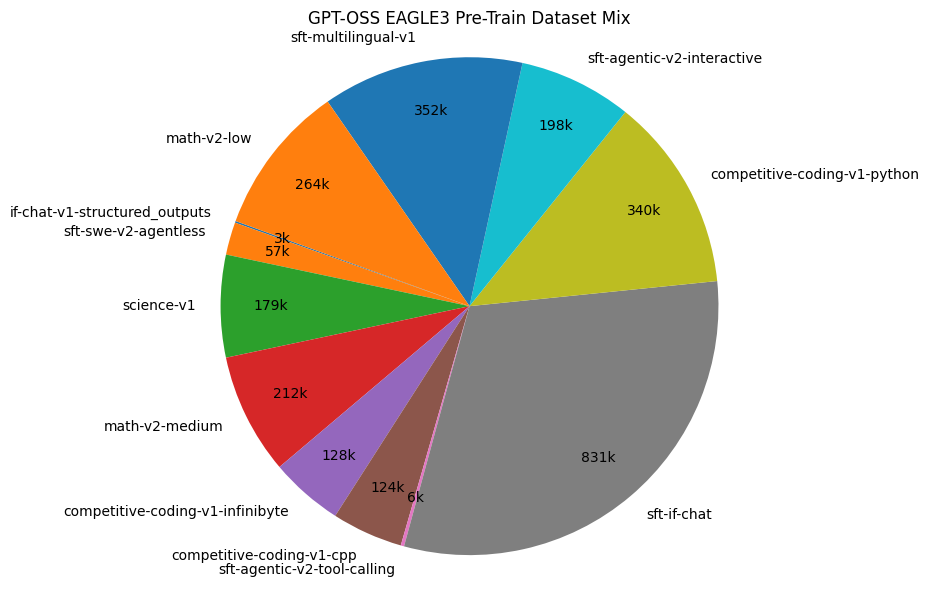

In [287]:
import matplotlib.pyplot as plt

data = lines_per_category

labels = list(data.keys())
sizes = list(data.values())
labels[3], labels[8] = labels[8], labels[3]
sizes[3], sizes[8] = sizes[8], sizes[3]

total = sum(sizes)
def format_absolute_k(pct):
    # Reverse-engineer the absolute value from the percentage
    absolute_val = (pct / 100.0) * total
    
    # Round to the nearest thousand and format as an integer with 'k'
    rounded_k = int(round(absolute_val / 1000))
    return f"{rounded_k}k"

plt.figure(figsize=(9, 6))
plt.pie(
    sizes, 
    labels=labels,
    # autopct='%1.1f%%',
    autopct=format_absolute_k,
    startangle=160,
    pctdistance=0.8
)

plt.title("GPT-OSS EAGLE3 Pre-Train Dataset Mix")

plt.axis('equal')
plt.tight_layout()

# Save the plot
plt.savefig("gpt-oss-eagle3-pretrain-dataset-mix.png", dpi=300)

plt.show()
